# Assignment: Pandas Fundamentals with Earthquake Data

In this assignment, we will review pandas fundamentals, such as how to

- Open csv files
- Manipulate dataframe indexes
- Parse date columns
- Examine basic dataframe statistics
- Manipulate text columns and extract values
- Plot dataframe contents using
  - Bar charts
  - Histograms
  - Scatter plots

First, import Numpy, Pandas and Matplotlib and set the display options.

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Data for this assignment in .csv format downloaded from the [USGS Earthquakes Database](https://earthquake.usgs.gov/earthquakes/search/) is available at:

https://dsrs.atmos.umd.edu/DATA/445Files/all_month.csv

You don't need to download this file. You can open it directly with Pandas.

### 1) Use Pandas' read_csv function directly on this URL to open it as a DataFrame
(Don't use any special options). Display the first few rows and the DataFrame info. (2 pt)

In [3]:
df = pd.read_csv('https://dsrs.atmos.umd.edu/DATA/445Files/all_month.csv')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-15T21:41:26.917Z,60.802000,-150.700000,27.30,1.80,ml,29,80,0.20000,1.20,...,2026-02-15T21:43:30.628Z,"13 km S of Point Possession, Alaska",earthquake,3.30,1.8956,0.30,6.0,automatic,ak,ak
1,2026-02-15T21:23:14.890Z,38.815834,-122.818832,1.04,1.01,md,5,126,0.01019,0.01,...,2026-02-15T21:24:53.179Z,"7 km NW of The Geysers, CA",earthquake,0.51,1.3200,0.53,8.0,automatic,nc,nc
2,2026-02-15T21:04:32.750Z,38.813999,-122.816330,1.18,0.72,md,15,110,0.01058,0.03,...,2026-02-15T21:06:07.970Z,"7 km NW of The Geysers, CA",earthquake,0.25,0.5700,0.21,15.0,automatic,nc,nc
3,2026-02-15T21:04:10.020Z,38.813667,-122.815834,1.27,2.53,md,44,50,0.01071,0.05,...,2026-02-15T21:07:39.210Z,"7 km NW of The Geysers, CA",earthquake,0.13,0.2000,0.18,49.0,automatic,nc,nc
4,2026-02-15T20:54:37.098Z,-15.119600,-173.310200,10.00,5.30,mb,53,61,2.79500,0.68,...,2026-02-15T21:13:37.040Z,"106 km NNE of Hihifo, Tonga",earthquake,10.97,1.8680,0.03,373.0,reviewed,us,us


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10498 entries, 0 to 10497
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             10498 non-null  object 
 1   latitude         10498 non-null  float64
 2   longitude        10498 non-null  float64
 3   depth            10498 non-null  float64
 4   mag              10496 non-null  float64
 5   magType          10496 non-null  object 
 6   nst              10498 non-null  int64  
 7   gap              10498 non-null  int64  
 8   dmin             10463 non-null  float64
 9   rms              10498 non-null  float64
 10  net              10498 non-null  object 
 11  id               10498 non-null  object 
 12  updated          10498 non-null  object 
 13  place            10498 non-null  object 
 14  type             10498 non-null  object 
 15  horizontalError  10155 non-null  float64
 16  depthError       10405 non-null  float64
 17  magError    

You should have seen that the dates were not automatically parsed into datetime types.

### 2) Re-read the data in such a way that the date columns are identified as dates and the earthquake ID is used as the index

Verify that this worked using the `head` and `info` functions. (1 pt)


In [5]:
df = pd.read_csv('https://dsrs.atmos.umd.edu/DATA/445Files/all_month.csv',parse_dates=[0])
df.head 

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-02-15 21:41:26.917000+00:00,60.802000,-150.700000,27.30,1.80,ml,29,80,0.20000,1.20,...,2026-02-15T21:43:30.628Z,"13 km S of Point Possession, Alaska",earthquake,3.30,1.8956,0.30,6.0,automatic,ak,ak
1,2026-02-15 21:23:14.890000+00:00,38.815834,-122.818832,1.04,1.01,md,5,126,0.01019,0.01,...,2026-02-15T21:24:53.179Z,"7 km NW of The Geysers, CA",earthquake,0.51,1.3200,0.53,8.0,automatic,nc,nc
2,2026-02-15 21:04:32.750000+00:00,38.813999,-122.816330,1.18,0.72,md,15,110,0.01058,0.03,...,2026-02-15T21:06:07.970Z,"7 km NW of The Geysers, CA",earthquake,0.25,0.5700,0.21,15.0,automatic,nc,nc
3,2026-02-15 21:04:10.020000+00:00,38.813667,-122.815834,1.27,2.53,md,44,50,0.01071,0.05,...,2026-02-15T21:07:39.210Z,"7 km NW of The Geysers, CA",earthquake,0.13,0.2000,0.18,49.0,automatic,nc,nc
4,2026-02-15 20:54:37.098000+00:00,-15.119600,-173.310200,10.00,5.30,mb,53,61,2.79500,0.68,...,2026-02-15T21:13:37.040Z,"106 km NNE of Hihifo, Tonga",earthquake,10.97,1.8680,0.03,373.0,reviewed,us,us


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10498 entries, 0 to 10497
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             10498 non-null  datetime64[ns, UTC]
 1   latitude         10498 non-null  float64            
 2   longitude        10498 non-null  float64            
 3   depth            10498 non-null  float64            
 4   mag              10496 non-null  float64            
 5   magType          10496 non-null  object             
 6   nst              10498 non-null  int64              
 7   gap              10498 non-null  int64              
 8   dmin             10463 non-null  float64            
 9   rms              10498 non-null  float64            
 10  net              10498 non-null  object             
 11  id               10498 non-null  object             
 12  updated          10498 non-null  object             
 13  place           

### 3) Use `describe` to get the basic statistics of all the columns

Note the highest and lowest magnitude of earthquakes in the databse. (2 pt)

In [7]:
df.describe()

# max = 6.4 min = -1.77 this makes sense because the magnitude is on a log scale!

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,10498.000000,10498.000000,10498.000000,10496.000000,10498.000000,10498.000000,10463.000000,10498.000000,10155.000000,10405.000000,10454.000000,10490.000000
mean,40.036259,-112.783225,19.382802,1.637384,26.673652,103.166508,0.404720,0.309292,2.603821,2.654198,0.196740,17.875596
std,17.261174,62.773620,46.249400,1.197425,22.881202,63.197627,1.290587,0.304891,4.844831,5.033273,0.126349,27.266342
min,-67.524000,-179.997000,-3.420000,-1.770000,0.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.528917,-148.116000,3.442500,0.900000,12.000000,58.000000,0.026410,0.100000,0.260000,0.500000,0.112266,7.000000
50%,38.770666,-121.947668,6.965000,1.500000,20.000000,84.000000,0.083180,0.180000,0.570000,0.970000,0.177750,12.000000
75%,57.247500,-116.102417,12.719250,2.010000,34.000000,129.000000,0.300000,0.500000,3.600000,2.680000,0.240337,21.000000
max,69.505000,179.933700,638.180000,6.400000,286.000000,358.000000,40.358000,4.100000,137.400000,81.197400,1.600000,605.000000


### 4) Use `nlargest` to get the top 20 earthquakes by magnitude

https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.nlargest.html
(1 pt)

In [8]:
df.nlargest(n=20,columns='mag')

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
362,2026-02-14 02:27:37.951000+00:00,-14.8934,166.6013,10.000,6.4,mww,111,23,0.800,1.14,...,2026-02-15T02:54:18.182Z,"53 km WNW of Port-Olry, Vanuatu",earthquake,7.31,1.720,0.050,39.0,reviewed,us,us
840,2026-02-12 13:34:31.114000+00:00,-30.8012,-71.4451,36.885,6.2,mww,80,64,0.207,1.32,...,2026-02-13T21:56:03.410Z,"32 km SW of Ovalle, Chile",earthquake,4.04,6.950,0.056,31.0,reviewed,us,us
1408,2026-02-10 20:44:52.774000+00:00,-21.0396,-178.3348,510.944,6.2,mww,85,27,4.729,0.82,...,2026-02-11T21:13:41.665Z,Fiji region,earthquake,10.56,7.331,0.038,65.0,reviewed,us,us
7958,2026-01-22 12:42:34.200000+00:00,51.7914,158.5253,47.000,6.2,mww,117,44,1.236,1.06,...,2026-02-13T12:36:42.601Z,"127 km S of Vilyuchinsk, Russia",earthquake,7.47,1.895,0.037,69.0,reviewed,us,us
3398,2026-02-04 10:39:29.988000+00:00,-29.5951,-178.5952,184.162,6.1,mww,57,71,8.879,0.86,...,2026-02-05T11:04:31.538Z,"Kermadec Islands, New Zealand",earthquake,9.24,7.110,0.045,48.0,reviewed,us,us
8345,2026-01-21 16:37:43.141000+00:00,23.2002,142.6037,8.000,6.1,mww,180,40,3.897,0.91,...,2026-02-12T01:24:33.223Z,"Volcano Islands, Japan region",earthquake,7.97,1.814,0.048,41.0,reviewed,us,us
44,2026-02-15 15:58:48.801000+00:00,48.3271,154.5612,54.981,6.0,mww,60,76,5.372,0.65,...,2026-02-15T18:26:40.303Z,"284 km SSW of Severo-Kuril’sk, Russia",earthquake,10.62,6.834,0.061,26.0,reviewed,us,us
5288,2026-01-29 07:30:39.685000+00:00,-57.8373,-25.4819,68.084,6.0,mww,153,25,7.115,0.75,...,2026-01-30T07:56:46.880Z,South Sandwich Islands region,earthquake,9.44,4.407,0.047,43.0,reviewed,us,us
9584,2026-01-19 13:02:19.436000+00:00,-22.4395,170.3939,11.000,6.0,mww,127,38,2.730,0.79,...,2026-02-04T21:47:52.778Z,"277 km ESE of Tadine, New Caledonia",earthquake,8.18,1.719,0.040,60.0,reviewed,us,us
2678,2026-02-06 21:20:14.809000+00:00,-7.7516,130.1235,27.125,5.9,mww,76,22,3.215,1.08,...,2026-02-07T21:48:00.641Z,"Pulau Pulau Tanimbar, Indonesia",earthquake,6.80,4.914,0.071,19.0,reviewed,us,us


Examine the structure of the `place` column. The state / country information seems to be in there. How would you get it out?

### 5) Extract the state or country using Pandas [text data functions](https://pandas.pydata.org/pandas-docs/stable/text.html)

Add it as a new column to the dataframe called `country`. Note that some of the "countries" are actually U.S. states. (2 pt)

In [9]:
df['country'] = df.place.str.split(', ').str[-1]
df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
0,2026-02-15 21:41:26.917000+00:00,60.802000,-150.700000,27.300,1.80,ml,29,80,0.200000,1.20,...,"13 km S of Point Possession, Alaska",earthquake,3.30,1.8956,0.300000,6.0,automatic,ak,ak,Alaska
1,2026-02-15 21:23:14.890000+00:00,38.815834,-122.818832,1.040,1.01,md,5,126,0.010190,0.01,...,"7 km NW of The Geysers, CA",earthquake,0.51,1.3200,0.530000,8.0,automatic,nc,nc,CA
2,2026-02-15 21:04:32.750000+00:00,38.813999,-122.816330,1.180,0.72,md,15,110,0.010580,0.03,...,"7 km NW of The Geysers, CA",earthquake,0.25,0.5700,0.210000,15.0,automatic,nc,nc,CA
3,2026-02-15 21:04:10.020000+00:00,38.813667,-122.815834,1.270,2.53,md,44,50,0.010710,0.05,...,"7 km NW of The Geysers, CA",earthquake,0.13,0.2000,0.180000,49.0,automatic,nc,nc,CA
4,2026-02-15 20:54:37.098000+00:00,-15.119600,-173.310200,10.000,5.30,mb,53,61,2.795000,0.68,...,"106 km NNE of Hihifo, Tonga",earthquake,10.97,1.8680,0.030000,373.0,reviewed,us,us,Tonga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10493,2026-01-16 22:28:28.220000+00:00,38.818832,-122.841499,2.030,0.97,md,13,130,0.006621,0.02,...,"9 km WNW of The Geysers, CA",earthquake,0.30,0.5500,0.380000,14.0,automatic,nc,nc,CA
10494,2026-01-16 22:23:08.630000+00:00,40.722667,-123.727333,26.350,1.91,md,40,37,0.022370,0.13,...,"25 km SSW of Willow Creek, CA",earthquake,0.24,0.5400,0.224000,26.0,reviewed,nc,nc,CA
10495,2026-01-16 22:15:37.580000+00:00,48.340667,-122.783500,23.050,1.80,ml,45,34,0.080250,0.12,...,"8 km W of Ault Field, Washington",earthquake,0.16,0.3700,0.137745,29.0,reviewed,uw,uw,Washington
10496,2026-01-16 22:07:34.396000+00:00,-4.436600,143.930500,131.053,4.80,mb,69,89,3.745000,0.83,...,"44 km SSW of Angoram, Papua New Guinea",earthquake,7.98,6.2650,0.065000,74.0,reviewed,us,us,Papua New Guinea


### 6) Display each unique value from the new column

https://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.unique.html (1 pt)

In [10]:
df.country.unique()

array(['Alaska', 'CA', 'Tonga', 'Texas', 'Hawaii', 'Russia', 'Indonesia',
       'Puerto Rico', 'Oklahoma', 'Chile', 'Ecuador', 'Peru', 'Missouri',
       'Nevada', 'Dominican Republic', 'Japan', 'Afghanistan', 'Greece',
       'Turkey', 'Banda Sea', 'West Chile Rise', 'Philippines',
       'Fiji region', 'Colombia', 'New Mexico', 'Argentina',
       'Cayman Islands', 'Solomon Islands', 'Washington',
       'U.S. Virgin Islands', 'Vanuatu', 'Utah', 'Tennessee',
       'Timor Leste', 'South Carolina', 'New Jersey', 'Iran',
       'Papua New Guinea', 'Fiji', 'North Carolina', 'MX', 'Pakistan',
       'Mexico', 'Montana', 'China', 'California', 'Wyoming', 'Guam',
       'Idaho', 'Canada', 'Taiwan', 'Oregon', 'east of the Kuril Islands',
       'Vietnam', 'NV', 'Kosovo', 'south of Panama',
       'Tristan da Cunha region', 'Jamaica', 'Tajikistan', 'Portugal',
       'Carlsberg Ridge', 'Arizona', 'Panama', 'Cuba',
       'Saint Eustatius and Saba ', 'Costa Rica', 'Anguilla',
       'Madagas

### 7) Create a filtered dataset that only has earthquakes of magnitude 4 or larger
(2 pt)

In [11]:
dfnew = df[df.mag>4]
dfnew

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
4,2026-02-15 20:54:37.098000+00:00,-15.1196,-173.3102,10.000,5.3,mb,53,61,2.795,0.68,...,"106 km NNE of Hihifo, Tonga",earthquake,10.97,1.868,0.030,373.0,reviewed,us,us,Tonga
20,2026-02-15 18:28:44.061000+00:00,51.2620,-169.2440,10.000,4.3,mb,51,186,1.729,0.81,...,"188 km S of Nikolski, Alaska",earthquake,7.47,1.942,0.054,95.0,reviewed,us,us,Alaska
44,2026-02-15 15:58:48.801000+00:00,48.3271,154.5612,54.981,6.0,mww,60,76,5.372,0.65,...,"284 km SSW of Severo-Kuril’sk, Russia",earthquake,10.62,6.834,0.061,26.0,reviewed,us,us,Russia
63,2026-02-15 13:44:06.602000+00:00,-11.4831,117.9622,10.000,4.9,mb,54,63,2.645,0.50,...,"266 km SSW of Tambolaka, Indonesia",earthquake,7.99,1.829,0.086,43.0,reviewed,us,us,Indonesia
73,2026-02-15 12:46:02.903000+00:00,-2.7274,140.6332,10.000,4.4,mb,22,141,0.223,1.42,...,"14 km S of Abepura, Indonesia",earthquake,6.68,1.766,0.143,14.0,reviewed,us,us,Indonesia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10480,2026-01-17 00:16:17.313000+00:00,29.8969,142.1796,10.000,5.0,mb,90,104,3.791,0.77,...,"Izu Islands, Japan region",earthquake,10.35,1.850,0.051,122.0,reviewed,us,us,Japan region
10483,2026-01-16 23:50:44.852000+00:00,-3.3817,128.6661,66.013,5.1,mww,77,49,1.676,0.86,...,"28 km W of Amahai, Indonesia",earthquake,6.68,6.063,0.103,9.0,reviewed,us,us,Indonesia
10485,2026-01-16 23:22:24.574000+00:00,56.4004,163.2860,32.727,5.2,mww,60,144,4.321,0.99,...,"53 km ENE of Ust’-Kamchatsk Staryy, Russia",earthquake,12.50,6.185,0.078,16.0,reviewed,us,us,Russia
10489,2026-01-16 23:05:39.231000+00:00,15.0757,-97.5406,10.000,4.2,mb,21,212,0.992,0.87,...,"99 km SSW of La Barra de Colotepec, Mexico",earthquake,3.42,1.966,0.214,6.0,reviewed,us,us,Mexico


### 8) Using the filtered dataset (magnitude > 4), count the number of earthquakes in each country/state. Make a bar chart of this number for the top 5 locations with the most earthquakes

Location name on the x axis, Earthquake count on the y axis.  Explain how your commands work (3 pt)

<Axes: xlabel='country'>

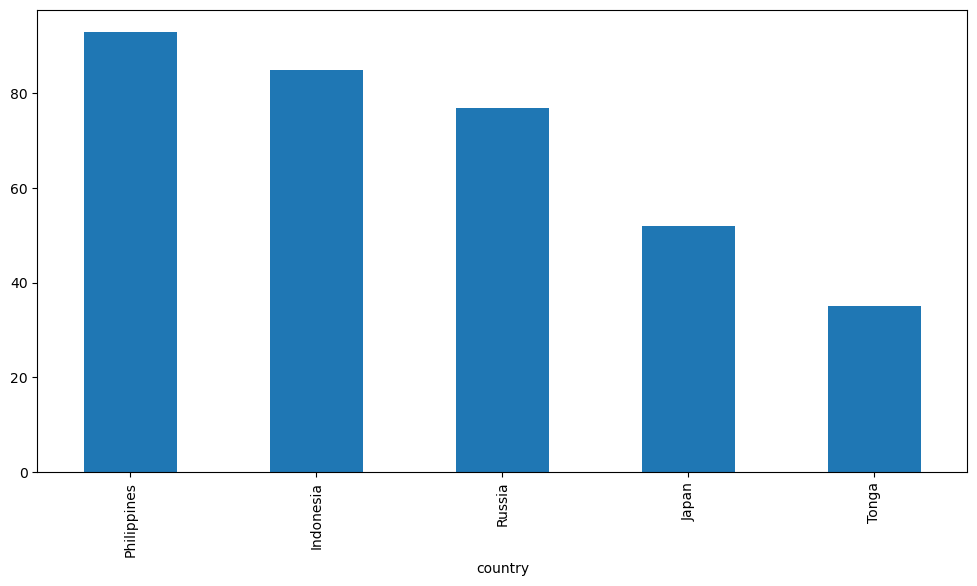

In [13]:
dfnew.groupby('country').mag.count().nlargest(5).plot(kind='bar', figsize=(12,6))

### 9) Make a histogram the distribution of the Earthquake magnitudes

https://pandas.pydata.org/pandas-docs/version/0.23/generated/pandas.DataFrame.hist.html
https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html

Do one subplot for the filtered and one for the unfiltered dataset.
Use a Logarithmic scale. What sort of relationship do you see? (3 pt)

Text(0.5, 0, 'Magnitude')

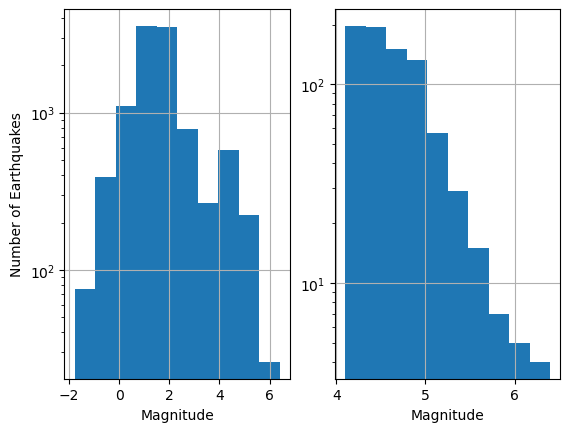

In [24]:
plt.figure()
plt.subplot(1,2,1)
df.mag.hist(log=True)
plt.xlabel('Magnitude')
plt.ylabel('Number of Earthquakes')

plt.subplot(1,2,2)
dfnew.mag.hist(log=True)
plt.xlabel('Magnitude')


### 10) Visualize the locations of earthquakes by making a scatterplot of their latitude and longitude

Use a two-column subplot with both the filtered and unfiltered datasets. Color the points by magnitude. Make it pretty

What difference do you note between the filtered and unfiltered datasets?

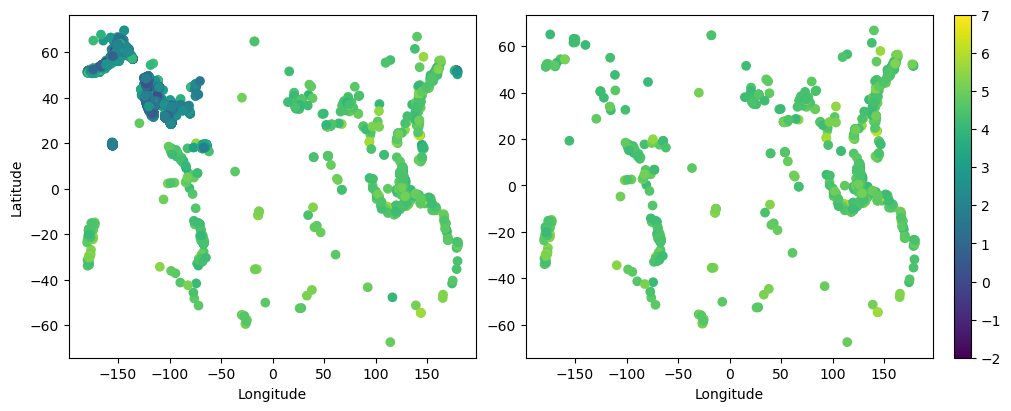

In [36]:
plt.figure(figsize=(10, 4),layout='constrained')
plt.subplot(1,2,1)
plt.scatter(df.longitude,df.latitude,c=df.mag,vmin=-2,vmax=7)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.subplot(1,2,2)
plt.scatter(dfnew.longitude,dfnew.latitude,c=dfnew.mag,vmin=-2,vmax=7)
plt.xlabel('Longitude')
plt.colorbar()